# Data Driven Models: Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

print("packages imported")

packages imported


## Learning Goals

* Describe halfspaces and decision boundaries for multivariable logistic functions
* Compute optimal parameters for logistic model using `sklearn`
* Determine appropriate regularization parameters graphically for logistic regression
* Determine the accuracy of model by using testing data set

## Prelecture Readings

* [MATH 360 > Logistic Regression > Multivariable Logistic Functions](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/multivariable.html)
* [MATH 360 > Logistic Regression > Model Evaluation](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/evaluation.html)

## NOTES

$\mathbf{W}$ is the weight vector for the decision plane, it points to class=1. By changing the weights of $W$ it rotates the plane 

## Rice Data

The data `rice.csv` is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik). The features are all lengths and areas measured in pixels since the data was inferred from images of grains of rice. The target values are $y=0$ for "Cammeo" and $y=1$ for "Osmancik" which are different species of rice.

In [2]:
df = pd.read_csv('DATA/rice.csv')
df.head()

,area,perimeter,major axis length,minor axis length,eccentricity,convex area,extent,target
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,0
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,0
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,0
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,0
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,0


Save the data and targets as NumPy arrays:

In [3]:
X1 = df.iloc[:,:7].values
y1 = df['target'].values

## Exercise 1: Decision Boundary

There are 7 features in the data but let's begin by selecting only 2 so that we can visualize the data and the decision boundaries.

**Create a scatter plot** using the features "major axis length" versus "minor axis length" and use the targer value as the color.

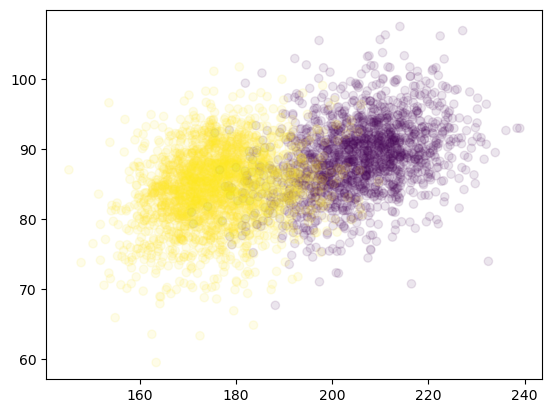

In [4]:
plt.scatter(X1[:,2], X1[:,3], c=y1, alpha=0.1)

**Look at the figure above and find parameters** $\mathbf{W}$ and $b$ (just by inspection) which define a decision boundary for the data $\langle \mathbf{W}, \mathbf{x} \rangle + b = 0$. Plot the line corresponding to $\mathbf{W}$ and $b$ with the data above to verify your choice of parameters.

In [ ]:
# something slanty from left to right

**Use `LogisticRegression` to construct a logistic regression model**. Use regularization parameter $C=1$. Compare the parameters with your prediction above.

Note that the function `LogisticRegression` gives a warning if you use pandas dataframe objects for the data. Use Numpy arrays to avoid the warning.

In [10]:
model = LogisticRegression(C =1).fit(X1[:,[2,3]], y1)

In [11]:
model.coef_

array([[-0.26644437, -0.01419318]])

In [12]:
model.intercept_

array([52.26288465])

**Create the contour plot of the logistic function** $\sigma(\mathbf{x}; \mathbf{W}, b)$ for the computed model parameters. Plot the contour plot with the data.

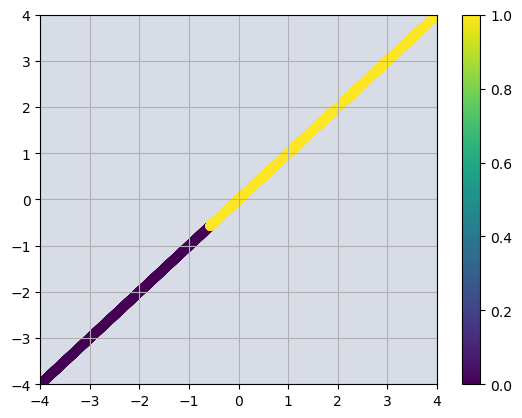

In [16]:
x0 = np.linspace(-4,4,3810); x1 = np.linspace(-4,4,3810);
X0,X1 = np.meshgrid(x0,x1)

W0 = model.coef_[0,0]; W1 = model.coef_[0,1]; b = model.intercept_[0]
Y = 1/(1 + np.exp(-(W0*X0 + W1*X1 + b)))
plt.contourf(X0,X1,Y,levels=10,alpha=0.2)
plt.contour(X0,X1,Y,levels=[0.5],colors='r')

plt.scatter(X1[:,0],X1[:,1],c=y1)
plt.grid(True), plt.colorbar()
plt.show()

## Exercise 2: Model accuracy

The function `train_test_split` separates the data into a training set and a testing set. The function `score` computes the accuracy of our model. Use the functions `train_test_split` and `score` to compute the accuracy of each model constructed from a pair of the features. (Use regularization parameter $C=1$ for each model.) Once you found the best features, create the scatter plot of the data in 2D using these features and plot the logistic function and the decision boundary.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.3)

## Exercise 3: Regularization parameter

Let's now use all 7 features to construct a logistic regression model. Construct models using several different values of the regularization parameter from $\alpha = 10^{-4}$ to $\alpha=10^4$. Compute the cross entropy and the regularization term $\Vert \mathbf{W} \Vert^2$ for each $\alpha$. Create the scatter plot of cross entropy versus $\Vert \mathbf{W} \Vert^2$ with color corresponding to $\alpha$.

See [Regularization Analysis](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/evaluation.html#regularization-analysis) from the course notes.

In [26]:
def costCE(W,b,X,y):
    N,p = X.shape
    W = np.array(W).reshape(p,1)
    y = np.array(y).reshape(N,1)
    S = 1/(1 + np.exp(-(X@W + b)))
    L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
    return L

Inspect the figure created above and determine a good value of $\alpha$. Compute the accuracy of the logistic regression model using the function `train_test_split` and `score`. Is the accuracy much better using 7 features compared just 2?

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/835874551.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/3590503030.py:6: RuntimeWarning: divide by zero encountered in log
  L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/3590503030.py:6: RuntimeWarning: invalid value encountered in multiply
  L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/3590503030.py:6: RuntimeWarning: divide by zero encountered in log
  L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/3590503030.py:6: RuntimeWarning: invalid value encountered in multiply
  L = -1/N*n

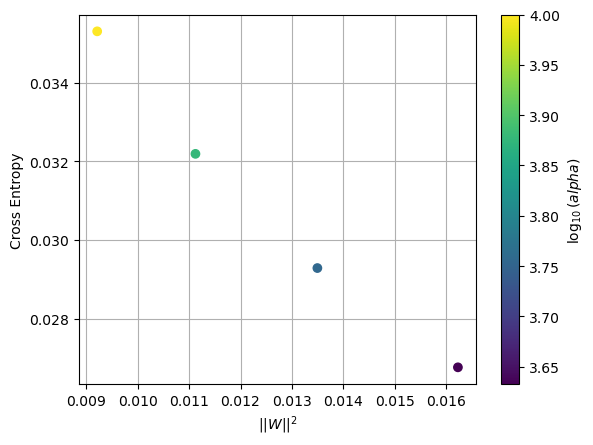

In [27]:
CEs = []
Rs = []
alphas = np.logspace(-2,4,50)
for alpha in alphas:
    model = LogisticRegression(C=1/alpha).fit(X_train,y_train)
    W = model.coef_
    b = model.intercept_
    CE = costCE(W,b,X_train, y_train)
    R = np.linalg.norm(W)**2
    CEs.append(CE)
    Rs.append(R)

plt.scatter(Rs,CEs,c=np.log10(alphas))
plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')
plt.xlabel('$|| W ||^2$')
plt.ylabel('Cross Entropy')
plt.show()


In [28]:
alpha = 0.01
model = LogisticRegression(C=1/alpha).fit(X_train,y_train)
W = model.coef_
b = model.intercept_
CE = costCE(W,b,X_train,y_train)
R = np.linalg.norm(W)**2
print('Cross entropy cost  =',CE)
print('Regularization cost =',R)

Cross entropy cost  = nan
Regularization cost = 1.0282457186595735


/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/3590503030.py:6: RuntimeWarning: divide by zero encountered in log
  L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_39675/3590503030.py:6: RuntimeWarning: invalid value encountered in multiply
  L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))


## Exercise 4: Feature scaling

**Plot the distribution of each feature for each target value separately.** In other words, select the samples with target $y=0$ and plot the distribution of each feature, and then do the same for $y=1$. Are the ranges of the features similar or different? How might that effect the model?

The distributions show that each feature is on a different scale. For example, the values for area are much larger than the other features. This means that the "area" feature for example will contribute much more to the regularization term $\Vert \mathbf{W} \Vert^2$. We should scale each feature to mean 0 and variance 1.

**Compute a new data matrix `D` from `X` such that each column has mean 0 and variance 1.**

**Use the data matrix `D` to construct logistic regression models** for different values of the regularization parameter from $\alpha=10^{-2}$ to $\alpha=10^{4}$. Create a scatter plot for cross entropy versus $\Vert \mathbf{W} \Vert^2$ for each $\alpha$.

**Describe the differences between this figure and the figure in the previous exercise.**

**Compute a logistic regression model using a good value of the regularization parameter and compute the model accuracy.**

**Compare the parameters in this model to the previous exercise.**